# IntelliWell — NLP Maintenance Issue Classification

## Notebook 5

### Objective

Develop a Natural Language Processing (NLP) machine learning pipeline
for automatically classifying petroleum well maintenance reports.

The notebook will:

- Analyze maintenance report text
- Perform NLP preprocessing
- Extract text features using TF-IDF
- Train multiple classification models
- Compare model performance
- Select the best NLP classifier
- Export the trained model for the IntelliWell backend

### Models

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine (LinearSVC)

### Target Classes

- Pressure Issue
- Mechanical Issue
- Production Issue
- Leak
- Valve Issue
- Electrical Issue
- Normal Operation

SECTION 1 — Introduction & Setup

In [120]:
import os
import re
import string
import warnings
import pickle

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


SECTION 2 — Dataset

In [121]:
DATA_PATH = "maintenance_reports.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (700, 2)


,report_text,category
0,Rotating equipment shows signs of mechanical d...,Mechanical Issue
1,Power supply fluctuations observed during oper...,Electrical Issue
2,Casing leakage may be causing abnormal pressur...,Leak
3,Pump performance degraded during continuous op...,Mechanical Issue
4,Leak suspected in the production tubing. This ...,Leak


In [122]:
# ==========================================================
# Load Maintenance Reports
# ==========================================================

REPORT_PATH = "maintenance_reports.csv"

df = pd.read_csv(REPORT_PATH)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(df.shape)

df.head()

Dataset Loaded Successfully
(700, 2)


,report_text,category
0,Rotating equipment shows signs of mechanical d...,Mechanical Issue
1,Power supply fluctuations observed during oper...,Electrical Issue
2,Casing leakage may be causing abnormal pressur...,Leak
3,Pump performance degraded during continuous op...,Mechanical Issue
4,Leak suspected in the production tubing. This ...,Leak


In [123]:
# ==========================================================
# Dataset Information
# ==========================================================

print(df.info())

print()

print(df.isna().sum())

print()

print(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   report_text  700 non-null    str  
 1   category     700 non-null    str  
dtypes: str(2)
memory usage: 123.3 KB
None

report_text    0
category       0
dtype: int64

                                              report_text          category
count                                                 700               700
unique                                                700                 7
top     Rotating equipment shows signs of mechanical d...  Mechanical Issue
freq                                                    1               100


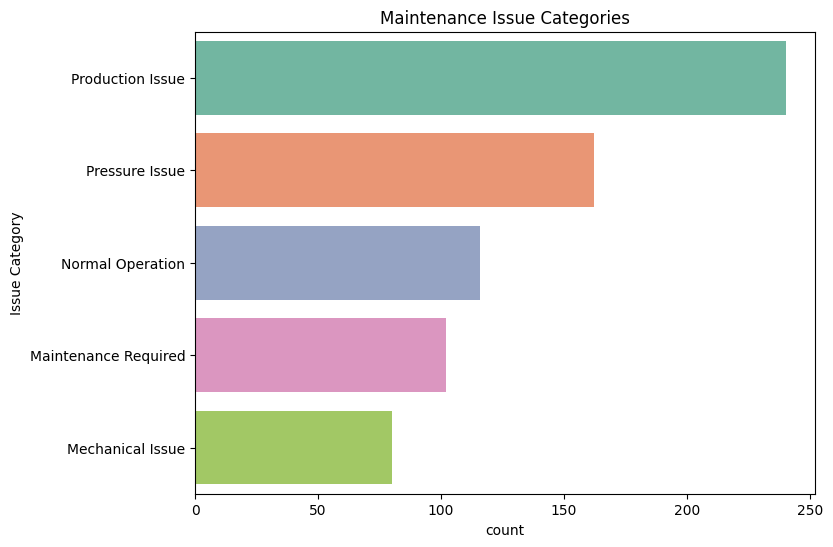

In [165]:
# ==========================================================
# Category Distribution
# ==========================================================

plt.figure(figsize=(8,6))

sns.countplot(

    data=df,

    y="Issue Category",

    order=df["Issue Category"].value_counts().index,

    palette="Set2"

)

plt.title("Maintenance Issue Categories")

plt.show()

SECTION 3 — NLP Exploratory Analysis

,Word,Frequency
0,condition,907
1,observed,755
2,production,346
3,monitoring,325
4,inspection,291
5,detected,224
6,operation,190
7,recommended,181
8,pressure,162
9,equipment,144


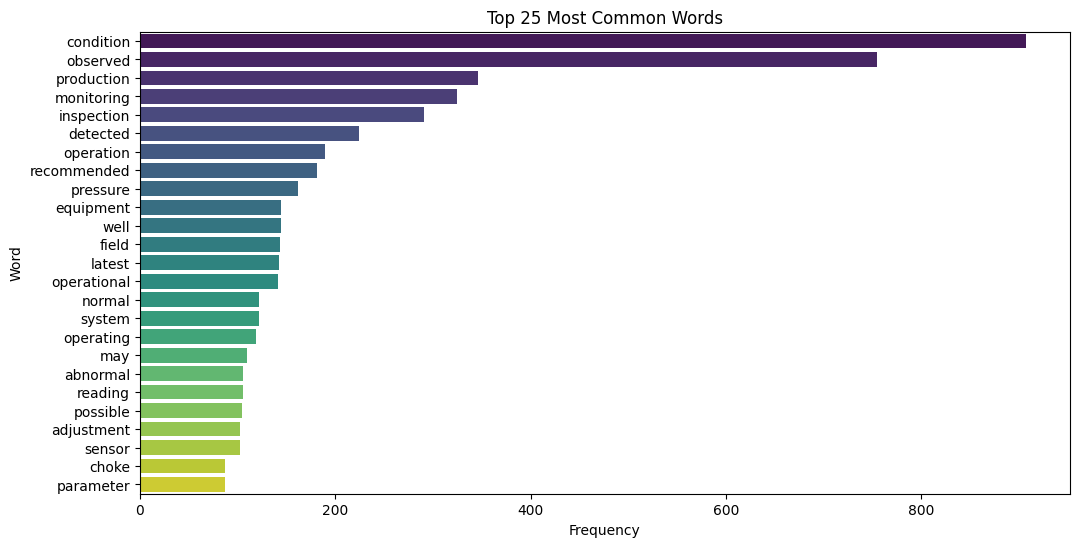

In [162]:
# ==========================================================
# Word Frequency Analysis
# ==========================================================

all_words = " ".join(df["Clean Report"])

tokens = all_words.split()

freq_dist = FreqDist(tokens)

word_freq = pd.DataFrame(

    freq_dist.most_common(25),

    columns=["Word", "Frequency"]

)

display(word_freq)

plt.figure(figsize=(12,6))

sns.barplot(
    data=word_freq,
    x="Frequency",
    y="Word",
    palette="viridis"
)

plt.title("Top 25 Most Common Words")

plt.show()

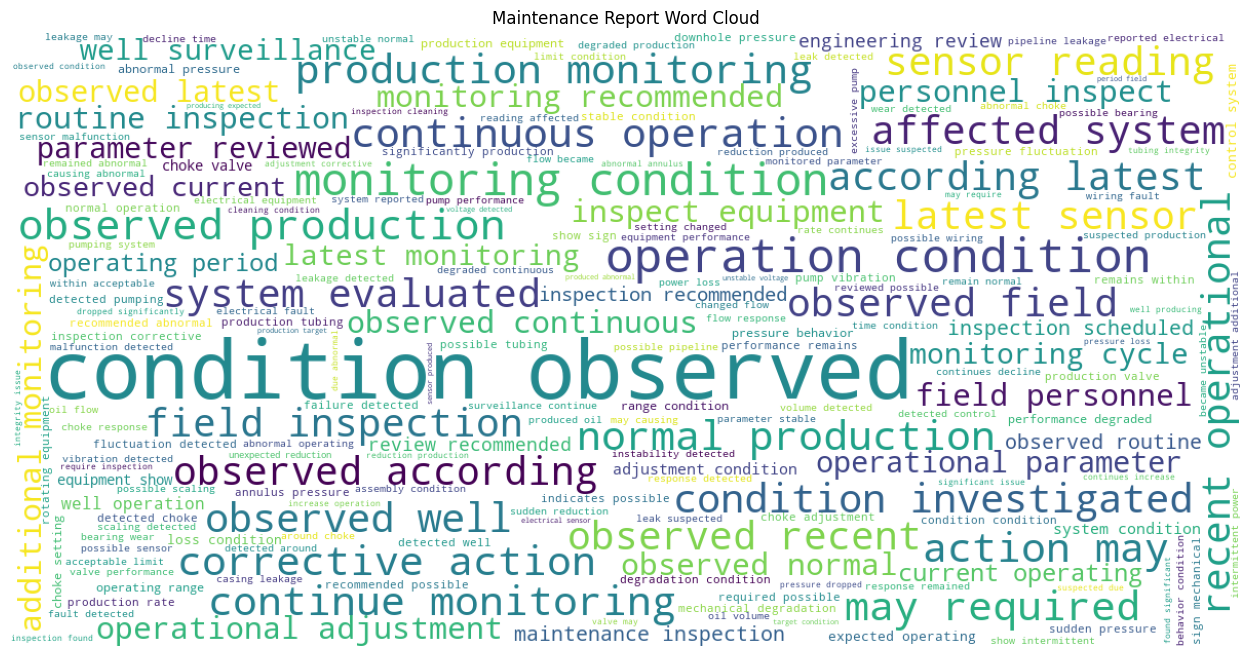

In [163]:
# ==========================================================
# Word Cloud
# ==========================================================

from wordcloud import WordCloud

text = " ".join(df["Clean Report"])

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color="white"

).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Maintenance Report Word Cloud")

plt.show()

In [164]:
# ==========================================================
# TF-IDF Keyword Extraction
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf.fit_transform(
    df["Clean Report"]
)

feature_names = tfidf.get_feature_names_out()

scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

keywords = pd.DataFrame({

    "Keyword": feature_names,

    "Importance": scores

})

keywords = keywords.sort_values(

    "Importance",

    ascending=False

)

display(keywords.head(20))

,Keyword,Importance
11,condition,0.122032
50,observed,0.100550
13,condition observed,0.093259
76,production,0.088311
44,monitoring,0.083101
33,inspection,0.080876
23,detected,0.062751
83,recommended,0.059055
63,operation,0.059005
75,pressure,0.052775


In [170]:
# ==========================================================
# Extract Top Keywords
# ==========================================================

def extract_keywords(text):

    words = text.split()

    words = list(dict.fromkeys(words))

    return ", ".join(words[:8])


df["Keywords"] = df["Clean Report"].apply(
    extract_keywords
)

display(

    df[

        [

            "report_text",

            "Keywords"

        ]

    ].head()

)

,report_text,Keywords
0,Rotating equipment shows signs of mechanical d...,"rotating, equipment, show, sign, mechanical, d..."
1,Power supply fluctuations observed during oper...,"power, supply, fluctuation, observed, operatio..."
2,Casing leakage may be causing abnormal pressur...,"casing, leakage, may, causing, abnormal, press..."
3,Pump performance degraded during continuous op...,"pump, performance, degraded, continuous, opera..."
4,Leak suspected in the production tubing. This ...,"leak, suspected, production, tubing, condition..."


## NLP Operational Analysis

In [168]:
# ==========================================================
# Automatic Summarization
# ==========================================================


def summarize_report(text):

    words = text.split()

    if len(words) <= 20:

        return text

    return " ".join(words[:20]) + "..."


df["Summary"] = df["report_text"].apply(
    summarize_report
)

display(

    df[

        [

            "report_text",

            "Summary"

        ]

    ].head()

)

,report_text,Summary
0,Rotating equipment shows signs of mechanical d...,Rotating equipment shows signs of mechanical d...
1,Power supply fluctuations observed during oper...,Power supply fluctuations observed during oper...
2,Casing leakage may be causing abnormal pressur...,Casing leakage may be causing abnormal pressur...
3,Pump performance degraded during continuous op...,Pump performance degraded during continuous op...
4,Leak suspected in the production tubing. This ...,Leak suspected in the production tubing. This ...


In [167]:
# ==========================================================
# Assign Risk Priority
# ==========================================================

def risk_priority(category):

    if category == "Safety":

        return "Critical"

    elif category == "Maintenance Required":

        return "High"

    elif category == "Pressure Issue":

        return "Medium"

    elif category == "Mechanical Issue":

        return "Medium"

    elif category == "Production Issue":

        return "Low"

    else:

        return "Normal"


df["Priority"] = df["Issue Category"].apply(
    risk_priority
)

display(df.head())

,report_text,category,Clean Report,Issue Category,Keywords,Summary,Priority
0,Rotating equipment shows signs of mechanical d...,Mechanical Issue,rotating equipment show sign mechanical degrad...,Maintenance Required,"rotating, equipment, show, sign, mechanical, d...",Rotating equipment shows signs of mechanical d...,High
1,Power supply fluctuations observed during oper...,Electrical Issue,power supply fluctuation observed operation co...,Normal Operation,"power, supply, fluctuation, observed, operatio...",Power supply fluctuations observed during oper...,Normal
2,Casing leakage may be causing abnormal pressur...,Leak,casing leakage may causing abnormal pressure b...,Pressure Issue,"casing, leakage, may, causing, abnormal, press...",Casing leakage may be causing abnormal pressur...,Medium
3,Pump performance degraded during continuous op...,Mechanical Issue,pump performance degraded continuous operation...,Mechanical Issue,"pump, performance, degraded, continuous, opera...",Pump performance degraded during continuous op...,Medium
4,Leak suspected in the production tubing. This ...,Leak,leak suspected production tubing condition obs...,Production Issue,"leak, suspected, production, tubing, condition...",Leak suspected in the production tubing. This ...,Low


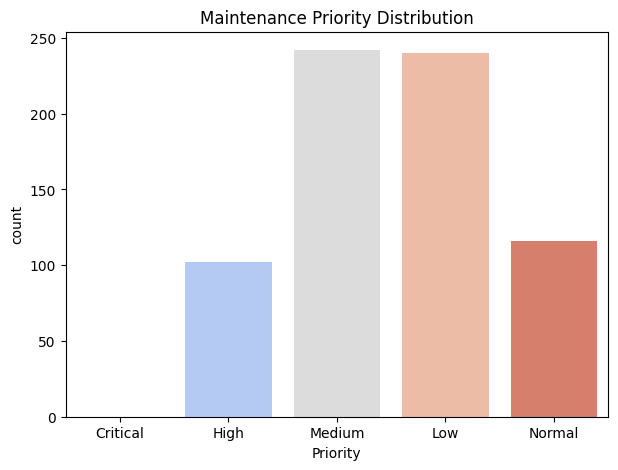

In [166]:
# ==========================================================
# Priority Distribution
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="Priority",

    order=[

        "Critical",

        "High",

        "Medium",

        "Low",

        "Normal"

    ],

    palette="coolwarm"

)

plt.title("Maintenance Priority Distribution")

plt.show()

In [169]:
# ==========================================================
# NLP Results
# ==========================================================

nlp_results = df[
    [
        "report_text",
        "Clean Report",
        "category",
        "Issue Category",
        "Keywords",
        "Summary",
        "Priority"
    ]
].copy()

# Generate unique report IDs
nlp_results.insert(
    0,
    "Report ID",
    range(1, len(nlp_results) + 1)
)

nlp_results.head()

,Report ID,report_text,Clean Report,category,Issue Category,Keywords,Summary,Priority
0,1,Rotating equipment shows signs of mechanical d...,rotating equipment show sign mechanical degrad...,Mechanical Issue,Maintenance Required,"rotating, equipment, show, sign, mechanical, d...",Rotating equipment shows signs of mechanical d...,High
1,2,Power supply fluctuations observed during oper...,power supply fluctuation observed operation co...,Electrical Issue,Normal Operation,"power, supply, fluctuation, observed, operatio...",Power supply fluctuations observed during oper...,Normal
2,3,Casing leakage may be causing abnormal pressur...,casing leakage may causing abnormal pressure b...,Leak,Pressure Issue,"casing, leakage, may, causing, abnormal, press...",Casing leakage may be causing abnormal pressur...,Medium
3,4,Pump performance degraded during continuous op...,pump performance degraded continuous operation...,Mechanical Issue,Mechanical Issue,"pump, performance, degraded, continuous, opera...",Pump performance degraded during continuous op...,Medium
4,5,Leak suspected in the production tubing. This ...,leak suspected production tubing condition obs...,Leak,Production Issue,"leak, suspected, production, tubing, condition...",Leak suspected in the production tubing. This ...,Low


SECTION 4 — Text Preprocessing

In [124]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))


def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [

        lemmatizer.lemmatize(word)

        for word in tokens

        if word not in stop_words

    ]

    return " ".join(tokens)

In [125]:
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'report_text'
1 'category'


In [126]:
# ==========================================================
# Clean Reports
# ==========================================================

df["Clean Report"] = df["report_text"].apply(clean_text)

df[["report_text", "Clean Report", "category"]].head()

,report_text,Clean Report,category
0,Rotating equipment shows signs of mechanical d...,rotating equipment show sign mechanical degrad...,Mechanical Issue
1,Power supply fluctuations observed during oper...,power supply fluctuation observed operation co...,Electrical Issue
2,Casing leakage may be causing abnormal pressur...,casing leakage may causing abnormal pressure b...,Leak
3,Pump performance degraded during continuous op...,pump performance degraded continuous operation...,Mechanical Issue
4,Leak suspected in the production tubing. This ...,leak suspected production tubing condition obs...,Leak


In [127]:
# ==========================================================
# Before vs After NLP Preprocessing
# ==========================================================

for i in range(5):

    print("=" * 70)

    print("ORIGINAL:")
    print(df.loc[i, "report_text"])

    print()

    print("CLEANED:")
    print(df.loc[i, "Clean Report"])

    print()

    print("CATEGORY:")
    print(df.loc[i, "category"])

ORIGINAL:
Rotating equipment shows signs of mechanical degradation. This condition was observed during the current operating period. Maintenance inspection should be scheduled.

CLEANED:
rotating equipment show sign mechanical degradation condition observed current operating period maintenance inspection scheduled

CATEGORY:
Mechanical Issue
ORIGINAL:
Power supply fluctuations observed during operation. This condition was observed after a recent operational adjustment. Additional monitoring is recommended.

CLEANED:
power supply fluctuation observed operation condition observed recent operational adjustment additional monitoring recommended

CATEGORY:
Electrical Issue
ORIGINAL:
Casing leakage may be causing abnormal pressure behavior. This condition was observed during normal production. The affected system should be evaluated.

CLEANED:
casing leakage may causing abnormal pressure behavior condition observed normal production affected system evaluated

CATEGORY:
Leak
ORIGINAL:
Pump pe

SECTION 5 — ML Dataset Preparation

In [171]:
# ==========================================================
# Rule-Based Issue Classification
# ==========================================================

def classify_issue(text):

    text = text.lower()

    if any(

        word in text

        for word in [

            "pressure",

            "annulus",

            "downhole"

        ]

    ):

        return "Pressure Issue"

    elif any(

        word in text

        for word in [

            "pump",

            "motor",

            "vibration"

        ]

    ):

        return "Mechanical Issue"

    elif any(

        word in text

        for word in [

            "production",

            "flow",

            "oil",

            "gas"

        ]

    ):

        return "Production Issue"

    elif any(

        word in text

        for word in [

            "leak",

            "inspection",

            "maintenance",

            "repair"

        ]

    ):

        return "Maintenance Required"

    elif any(

        word in text

        for word in [

            "safe",

            "hazard",

            "risk"

        ]

    ):

        return "Safety"

    else:

        return "Normal Operation"


df["Issue Category"] = df["Clean Report"].apply(
    classify_issue
)

display(df.head())

,report_text,category,Clean Report,Issue Category,Keywords,Summary,Priority
0,Rotating equipment shows signs of mechanical d...,Mechanical Issue,rotating equipment show sign mechanical degrad...,Maintenance Required,"rotating, equipment, show, sign, mechanical, d...",Rotating equipment shows signs of mechanical d...,High
1,Power supply fluctuations observed during oper...,Electrical Issue,power supply fluctuation observed operation co...,Normal Operation,"power, supply, fluctuation, observed, operatio...",Power supply fluctuations observed during oper...,Normal
2,Casing leakage may be causing abnormal pressur...,Leak,casing leakage may causing abnormal pressure b...,Pressure Issue,"casing, leakage, may, causing, abnormal, press...",Casing leakage may be causing abnormal pressur...,Medium
3,Pump performance degraded during continuous op...,Mechanical Issue,pump performance degraded continuous operation...,Mechanical Issue,"pump, performance, degraded, continuous, opera...",Pump performance degraded during continuous op...,Medium
4,Leak suspected in the production tubing. This ...,Leak,leak suspected production tubing condition obs...,Production Issue,"leak, suspected, production, tubing, condition...",Leak suspected in the production tubing. This ...,Low


In [128]:
# ==========================================================
# Features and Target
# ==========================================================

X = df["Clean Report"]
y = df["category"]

print("Number of reports:", len(X))
print("Number of classes:", y.nunique())

print("\nTarget classes:")
for category in sorted(y.unique()):
    print("-", category)

Number of reports: 700
Number of classes: 7

Target classes:
- Electrical Issue
- Leak
- Mechanical Issue
- Normal Operation
- Pressure Issue
- Production Issue
- Valve Issue


In [129]:
# ==========================================================
# Train/Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 560
Testing samples : 140

Training class distribution:
category
Valve Issue         80
Pressure Issue      80
Leak                80
Mechanical Issue    80
Production Issue    80
Normal Operation    80
Electrical Issue    80
Name: count, dtype: int64

Testing class distribution:
category
Electrical Issue    20
Valve Issue         20
Leak                20
Normal Operation    20
Mechanical Issue    20
Production Issue    20
Pressure Issue      20
Name: count, dtype: int64


In [130]:
# ==========================================================
# TF-IDF Feature Extraction
# ==========================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF transformation complete.")

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix :", X_test_tfidf.shape)

print(
    "Vocabulary size:",
    len(tfidf_vectorizer.get_feature_names_out())
)

TF-IDF transformation complete.
Training matrix: (560, 597)
Testing matrix : (140, 597)
Vocabulary size: 597


SECTION 6 — Model Development

In [131]:
# ==========================================================
# Model 1 — Logistic Regression
# ==========================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("=" * 50)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Logistic Regression Results
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [132]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

Electrical Issue       1.00      1.00      1.00        20
            Leak       1.00      1.00      1.00        20
Mechanical Issue       1.00      1.00      1.00        20
Normal Operation       1.00      1.00      1.00        20
  Pressure Issue       1.00      1.00      1.00        20
Production Issue       1.00      1.00      1.00        20
     Valve Issue       1.00      1.00      1.00        20

        accuracy                           1.00       140
       macro avg       1.00      1.00      1.00       140
    weighted avg       1.00      1.00      1.00       140



In [133]:
# ==========================================================
# Model 2 — Multinomial Naive Bayes
# ==========================================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_predictions = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Multinomial Naive Bayes Results")
print("=" * 50)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Multinomial Naive Bayes Results
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [134]:
# ==========================================================
# Model 3 — Linear SVM
# ==========================================================

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("Linear SVM Results")
print("=" * 50)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Linear SVM Results
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


SECTION 7 — Model Evaluation

In [135]:
# ==========================================================
# Model Comparison
# ==========================================================

model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        svm_accuracy
    ],

    "Precision": [
        logistic_precision,
        nb_precision,
        svm_precision
    ],

    "Recall": [
        logistic_recall,
        nb_recall,
        svm_recall
    ],

    "F1 Score": [
        logistic_f1,
        nb_f1,
        svm_f1
    ]

})

model_results = model_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
2,Linear SVM,1.0,1.0,1.0,1.0


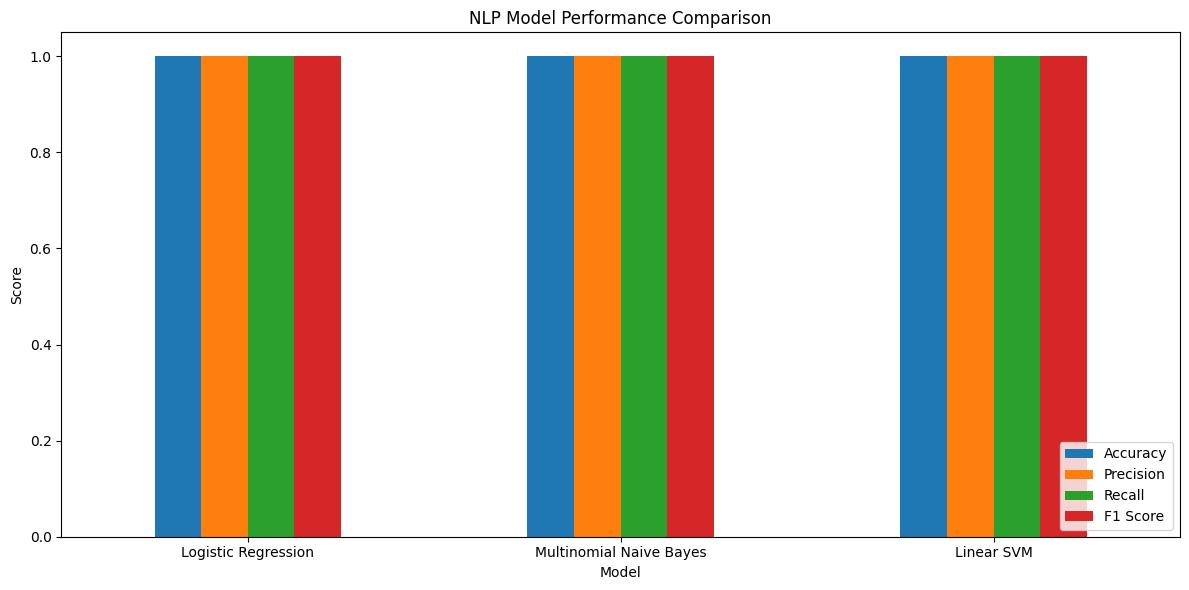

In [136]:
# ==========================================================
# Model Performance Visualization
# ==========================================================

comparison_plot = model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("NLP Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [137]:
# ==========================================================
# Select Best NLP Model
# ==========================================================

best_model_name = model_results.iloc[0]["Model"]
best_f1 = model_results.iloc[0]["F1 Score"]

print("=" * 60)
print("BEST NLP MODEL")
print("=" * 60)

print("Model   :", best_model_name)
print(f"F1 Score: {best_f1:.4f}")

BEST NLP MODEL
Model   : Logistic Regression
F1 Score: 1.0000


In [138]:
# ==========================================================
# Retrieve Best Model and Predictions
# ==========================================================

models = {
    "Logistic Regression": logistic_model,
    "Multinomial Naive Bayes": nb_model,
    "Linear SVM": svm_model
}

predictions = {
    "Logistic Regression": logistic_predictions,
    "Multinomial Naive Bayes": nb_predictions,
    "Linear SVM": svm_predictions
}

# Get best model name from comparison results
best_model_name = model_results.iloc[0]["Model"]

# Retrieve corresponding model
best_model = models[best_model_name]

# Retrieve corresponding predictions
best_predictions = predictions[best_model_name]

print("=" * 60)
print("BEST MODEL SELECTED")
print("=" * 60)

print("Model:", best_model_name)
print("Number of predictions:", len(best_predictions))

BEST MODEL SELECTED
Model: Logistic Regression
Number of predictions: 140


In [139]:
# ==========================================================
# Best Model Classification Report
# ==========================================================

print("=" * 70)
print(f"CLASSIFICATION REPORT — {best_model_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

CLASSIFICATION REPORT — Logistic Regression
                  precision    recall  f1-score   support

Electrical Issue       1.00      1.00      1.00        20
            Leak       1.00      1.00      1.00        20
Mechanical Issue       1.00      1.00      1.00        20
Normal Operation       1.00      1.00      1.00        20
  Pressure Issue       1.00      1.00      1.00        20
Production Issue       1.00      1.00      1.00        20
     Valve Issue       1.00      1.00      1.00        20

        accuracy                           1.00       140
       macro avg       1.00      1.00      1.00       140
    weighted avg       1.00      1.00      1.00       140



In [140]:
# ==========================================================
# Best Model Classification Report
# ==========================================================

print("=" * 70)
print(f"CLASSIFICATION REPORT — {best_model_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

CLASSIFICATION REPORT — Logistic Regression
                  precision    recall  f1-score   support

Electrical Issue       1.00      1.00      1.00        20
            Leak       1.00      1.00      1.00        20
Mechanical Issue       1.00      1.00      1.00        20
Normal Operation       1.00      1.00      1.00        20
  Pressure Issue       1.00      1.00      1.00        20
Production Issue       1.00      1.00      1.00        20
     Valve Issue       1.00      1.00      1.00        20

        accuracy                           1.00       140
       macro avg       1.00      1.00      1.00       140
    weighted avg       1.00      1.00      1.00       140



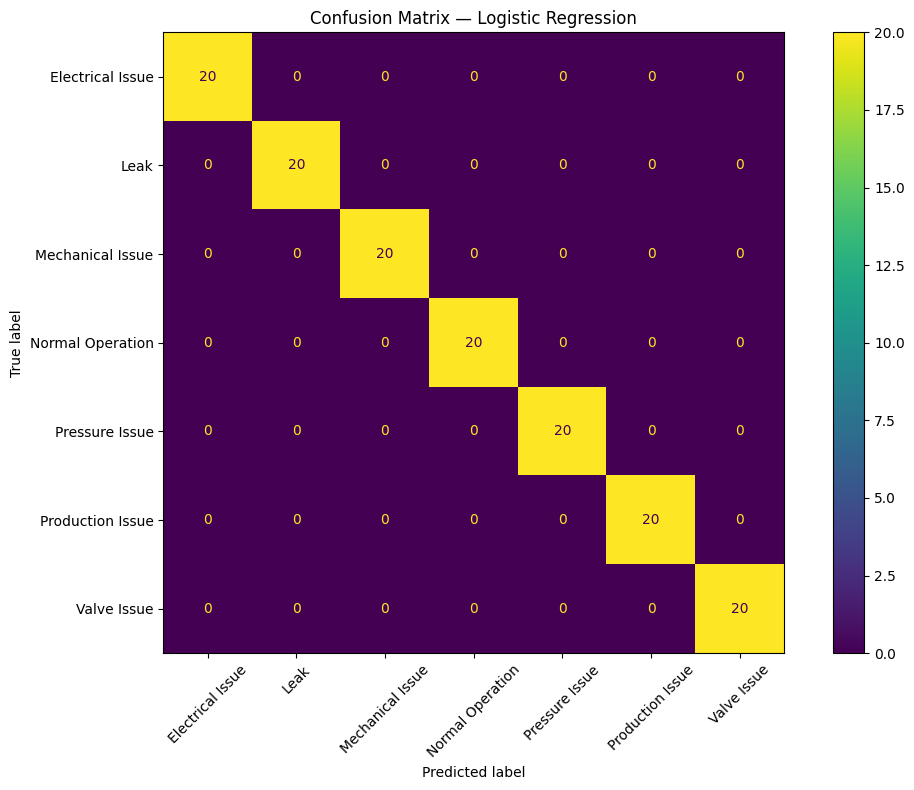

In [141]:
# ==========================================================
# Confusion Matrix
# ==========================================================

labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=labels
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.show()

In [142]:
# ==========================================================
# Prediction Error Analysis
# ==========================================================

error_analysis = pd.DataFrame({

    "Report": X_test.values,

    "Actual Category": y_test.values,

    "Predicted Category": best_predictions

})

error_analysis["Correct"] = (

    error_analysis["Actual Category"]

    ==

    error_analysis["Predicted Category"]

)

incorrect_predictions = error_analysis[
    error_analysis["Correct"] == False
].copy()

print(
    "Total test reports:",
    len(error_analysis)
)

print(
    "Correct predictions:",
    error_analysis["Correct"].sum()
)

print(
    "Incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions.head(20)

Total test reports: 140
Correct predictions: 140
Incorrect predictions: 0


,Report,Actual Category,Predicted Category,Correct


SECTION 8 — Model Validation

In [143]:
# ==========================================================
# Test Best Model on New Maintenance Reports
# ==========================================================

test_reports = [

    "Downhole pressure suddenly dropped after the choke was adjusted.",

    "Severe vibration detected in the pump and abnormal mechanical noise observed.",

    "Possible tubing leakage detected due to unexpected fluid loss.",

    "Electrical sensor is producing unstable voltage readings.",

    "Oil production rate has declined significantly during the last operating period.",

    "Choke valve appears blocked and is not responding correctly.",

    "Well pressure temperature and production remain stable with no abnormal conditions."

]


for report in test_reports:

    cleaned_report = clean_text(report)

    report_vector = tfidf_vectorizer.transform(
        [cleaned_report]
    )

    prediction = best_model.predict(
        report_vector
    )[0]

    print("=" * 80)

    print("REPORT:")
    print(report)

    print()

    print("PREDICTED CATEGORY:")
    print(prediction)

REPORT:
Downhole pressure suddenly dropped after the choke was adjusted.

PREDICTED CATEGORY:
Pressure Issue
REPORT:
Severe vibration detected in the pump and abnormal mechanical noise observed.

PREDICTED CATEGORY:
Mechanical Issue
REPORT:
Possible tubing leakage detected due to unexpected fluid loss.

PREDICTED CATEGORY:
Leak
REPORT:
Electrical sensor is producing unstable voltage readings.

PREDICTED CATEGORY:
Electrical Issue
REPORT:
Oil production rate has declined significantly during the last operating period.

PREDICTED CATEGORY:
Production Issue
REPORT:
Choke valve appears blocked and is not responding correctly.

PREDICTED CATEGORY:
Valve Issue
REPORT:
Well pressure temperature and production remain stable with no abnormal conditions.

PREDICTED CATEGORY:
Normal Operation


SECTION 9 — Production Model

In [144]:
# ==========================================================
# Final Model Training on Complete Dataset
# ==========================================================

print("Selected model:", best_model_name)

# Create final TF-IDF vectorizer
final_tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Learn vocabulary from the complete dataset
X_full_tfidf = final_tfidf_vectorizer.fit_transform(
    df["Clean Report"]
)

# Create a fresh instance of the selected model
if best_model_name == "Logistic Regression":

    final_model = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

elif best_model_name == "Multinomial Naive Bayes":

    final_model = MultinomialNB()

elif best_model_name == "Linear SVM":

    final_model = LinearSVC(
        random_state=42
    )

else:

    raise ValueError(
        f"Unknown model: {best_model_name}"
    )

# Train using all available reports
final_model.fit(
    X_full_tfidf,
    df["category"]
)

print("Final NLP model trained successfully.")
print("Training records:", X_full_tfidf.shape[0])
print("TF-IDF features:", X_full_tfidf.shape[1])

Selected model: Logistic Regression
Final NLP model trained successfully.
Training records: 700
TF-IDF features: 598


In [145]:
# ==========================================================
# Create NLP Model Directory
# ==========================================================

import os

MODEL_DIR = "../backend/models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print(
    "Model directory:",
    os.path.abspath(MODEL_DIR)
)

Model directory: e:\Simpi 2026\Projects\Our's\backend\models


In [146]:
# ==========================================================
# Save NLP Model + TF-IDF Vectorizer
# ==========================================================

import joblib

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "nlp_maintenance_classifier.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "nlp_tfidf_vectorizer.pkl"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

joblib.dump(
    final_tfidf_vectorizer,
    VECTORIZER_PATH
)

print("NLP artifacts saved successfully.")

print("\nModel:")
print(MODEL_PATH)

print("\nVectorizer:")
print(VECTORIZER_PATH)

NLP artifacts saved successfully.

Model:
../backend/models\nlp_maintenance_classifier.pkl

Vectorizer:
../backend/models\nlp_tfidf_vectorizer.pkl


In [147]:
# ==========================================================
# Verify Saved NLP Artifacts
# ==========================================================

print(
    "Model exists:",
    os.path.exists(MODEL_PATH)
)

print(
    "Vectorizer exists:",
    os.path.exists(VECTORIZER_PATH)
)

print(
    "Model size:",
    os.path.getsize(MODEL_PATH),
    "bytes"
)

print(
    "Vectorizer size:",
    os.path.getsize(VECTORIZER_PATH),
    "bytes"
)

Model exists: True
Vectorizer exists: True
Model size: 34719 bytes
Vectorizer size: 30108 bytes


In [148]:
# ==========================================================
# Reload Saved NLP Model
# ==========================================================

loaded_model = joblib.load(
    MODEL_PATH
)

loaded_vectorizer = joblib.load(
    VECTORIZER_PATH
)

print("Model loaded successfully:")
print(type(loaded_model))

print("\nVectorizer loaded successfully:")
print(type(loaded_vectorizer))

Model loaded successfully:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

Vectorizer loaded successfully:
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [149]:
# ==========================================================
# Deployment Test
# ==========================================================

deployment_reports = [

    "Sudden reduction in tubing pressure detected during production.",

    "Pump vibration increased and abnormal mechanical noise was observed.",

    "Possible leakage detected in the production tubing.",

    "Choke valve appears partially blocked.",

    "Electrical sensor reported unstable voltage readings.",

    "Oil production rate has declined significantly.",

    "Well is operating normally with stable pressure and temperature."
]


print("=" * 80)
print("INTELLIWELL NLP DEPLOYMENT TEST")
print("=" * 80)


for report in deployment_reports:

    cleaned = clean_text(report)

    vector = loaded_vectorizer.transform(
        [cleaned]
    )

    prediction = loaded_model.predict(
        vector
    )[0]

    print("\nREPORT:")
    print(report)

    print("PREDICTION:")
    print(prediction)

    print("-" * 80)

INTELLIWELL NLP DEPLOYMENT TEST

REPORT:
Sudden reduction in tubing pressure detected during production.
PREDICTION:
Pressure Issue
--------------------------------------------------------------------------------

REPORT:
Pump vibration increased and abnormal mechanical noise was observed.
PREDICTION:
Mechanical Issue
--------------------------------------------------------------------------------

REPORT:
Possible leakage detected in the production tubing.
PREDICTION:
Leak
--------------------------------------------------------------------------------

REPORT:
Choke valve appears partially blocked.
PREDICTION:
Valve Issue
--------------------------------------------------------------------------------

REPORT:
Electrical sensor reported unstable voltage readings.
PREDICTION:
Electrical Issue
--------------------------------------------------------------------------------

REPORT:
Oil production rate has declined significantly.
PREDICTION:
Production Issue
----------------------------

In [161]:
# ==========================================================
# Export Results
# ==========================================================

OUTPUT = "maintenance_analysis.csv"

nlp_results.to_csv(

    OUTPUT,

    index=False

)

print("=" * 60)

print("NLP Analysis Saved Successfully")

print(OUTPUT)

print("=" * 60)

NLP Analysis Saved Successfully
maintenance_analysis.csv


SECTION 10 — Conclusion

# Notebook 5 — Conclusion

The IntelliWell NLP maintenance classification pipeline was successfully
developed and evaluated.

## Pipeline

Maintenance Report  
↓  
Text Preprocessing  
↓  
TF-IDF Feature Extraction  
↓  
Multiple Machine Learning Classifiers  
↓  
Model Evaluation and Comparison  
↓  
Best Model Selection  
↓  
Model Export  
↓  
IntelliWell Backend Integration

## Models Evaluated

- Logistic Regression
- Multinomial Naive Bayes
- Linear Support Vector Machine

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix
- Error Analysis

The best-performing classifier was selected using weighted F1 score.

The final classifier and TF-IDF vectorizer were exported as serialized
model artifacts for integration with the IntelliWell Flask backend.

## Important Limitation

The current maintenance-report dataset is synthetic and was created for
development and demonstration of the NLP classification pipeline.

Therefore, the reported performance should not be interpreted as validated
performance on real field maintenance reports. Future work should evaluate
and retrain the system using real engineer-written maintenance records.